In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Choose a mean,standard deviation, and number of samples

def create_ages(mu=50,sigma=13,num_samples=100,seed=42):

    # Set a random seed in the same cell as the random call to get the same values as us
    # We set seed to 42 (42 is an arbitrary choice from Hitchhiker's Guide to the Galaxy)
    np.random.seed(seed)

    sample_ages = np.random.normal(loc=mu,scale=sigma,size=num_samples)
    sample_ages = np.round(sample_ages,decimals=0)
    
    return sample_ages

In [4]:
sample = create_ages()

In [6]:
sample

array([56., 48., 58., 70., 47., 47., 71., 60., 44., 57., 44., 44., 53.,
       25., 28., 43., 37., 54., 38., 32., 69., 47., 51., 31., 43., 51.,
       35., 55., 42., 46., 42., 74., 50., 36., 61., 34., 53., 25., 33.,
       53., 60., 52., 48., 46., 31., 41., 44., 64., 54., 27., 54., 45.,
       41., 58., 63., 62., 39., 46., 54., 63., 44., 48., 36., 34., 61.,
       68., 49., 63., 55., 42., 55., 70., 50., 70., 16., 61., 51., 46.,
       51., 24., 47., 55., 69., 43., 39., 43., 62., 54., 43., 57., 51.,
       63., 41., 46., 45., 31., 54., 53., 50., 47.])

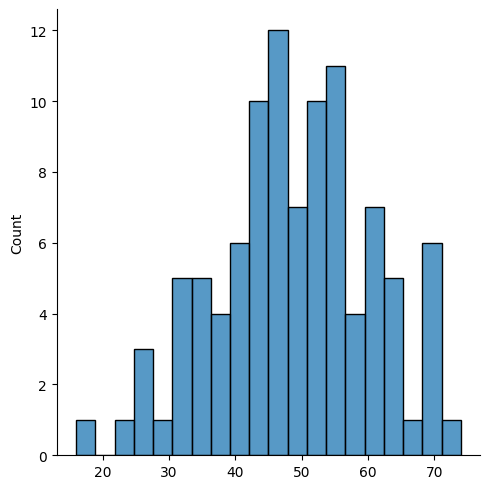

In [9]:
sns.displot(data=sample,bins=20)

<Axes: >

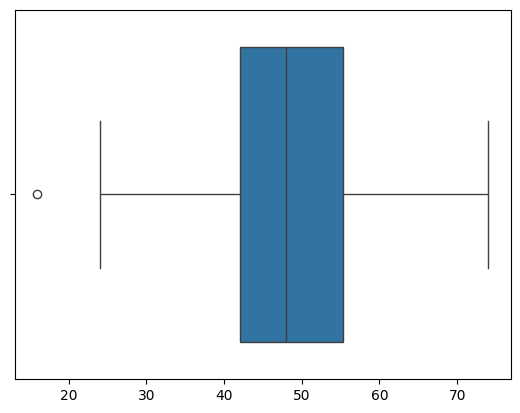

In [15]:
sns.boxplot(x=sample)

In [16]:
ser = pd.Series(sample)

In [19]:
ser.describe()

count    100.00000
mean      48.66000
std       11.82039
min       16.00000
25%       42.00000
50%       48.00000
75%       55.25000
max       74.00000
dtype: float64

In [22]:
iqr = 55.25 - 42
1.5*iqr

19.875

In [25]:
ll = 42 - 19.875

In [26]:
ul = 55.25 + 19.875

In [30]:
np.percentile(sample,[75,25])

array([55.25, 42.  ])

In [31]:
ser_trans = ser[(ser > ll) & (ser < ul)]

<Axes: xlabel='None'>

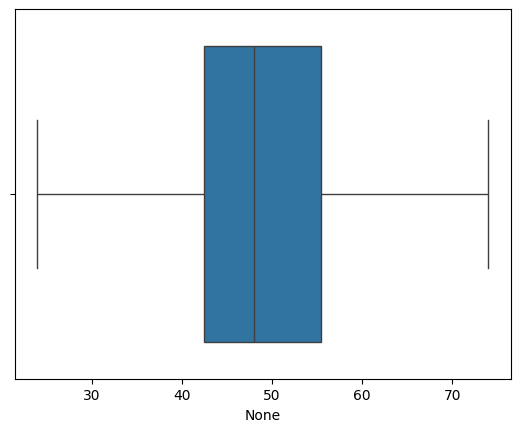

In [33]:
sns.boxplot(x=ser_trans)

In [34]:
df = pd.read_csv('../Excercises/DATA/Ames_Housing_data.csv')

In [40]:
df.corr(numeric_only = True)['SalePrice'].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

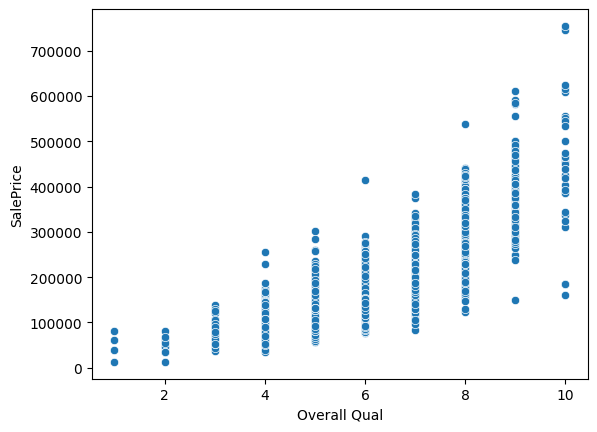

In [42]:
sns.scatterplot(data=df,x='Overall Qual',y='SalePrice')

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

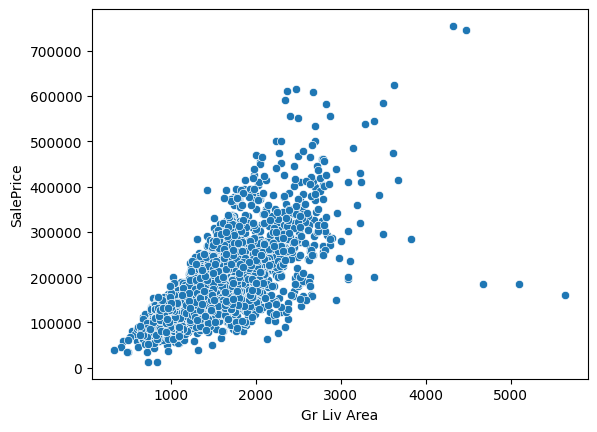

In [44]:
sns.scatterplot(data=df,x='Gr Liv Area',y='SalePrice')

In [46]:
df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 400000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [48]:
with open('../Excercises/DATA/Ames_Housing_Feature_Description.txt','r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [49]:
df = pd.read_csv('../Excercises/DATA/Ames_outliers_removed.csv')

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2927 entries, 0 to 2926
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2927 non-null   int64  
 1   MS SubClass      2927 non-null   int64  
 2   MS Zoning        2927 non-null   str    
 3   Lot Frontage     2437 non-null   float64
 4   Lot Area         2927 non-null   int64  
 5   Street           2927 non-null   str    
 6   Alley            198 non-null    str    
 7   Lot Shape        2927 non-null   str    
 8   Land Contour     2927 non-null   str    
 9   Utilities        2927 non-null   str    
 10  Lot Config       2927 non-null   str    
 11  Land Slope       2927 non-null   str    
 12  Neighborhood     2927 non-null   str    
 13  Condition 1      2927 non-null   str    
 14  Condition 2      2927 non-null   str    
 15  Bldg Type        2927 non-null   str    
 16  House Style      2927 non-null   str    
 17  Overall Qual     2927 non

In [54]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [56]:
df = df.drop('PID',axis=1)

In [61]:
(100 * df.isnull().sum()/len(df)).round(2)

MS SubClass        0.00
MS Zoning          0.00
Lot Frontage      16.74
Lot Area           0.00
Street             0.00
                  ...  
Mo Sold            0.00
Yr Sold            0.00
Sale Type          0.00
Sale Condition     0.00
SalePrice          0.00
Length: 80, dtype: float64

In [62]:
def pct_missing(df):
    pct_nan = (100 * df.isnull().sum()/len(df)).round(2)
    pct_nan = pct_nan[pct_nan > 0]
    return pct_nan

In [63]:
pct_nan = pct_missing(df)

In [68]:
pct_nan.sort_values(ascending=False)

Pool QC           99.59
Misc Feature      96.41
Alley             93.24
Fence             80.46
Mas Vnr Type      60.64
Fireplace Qu      48.58
Lot Frontage      16.74
Garage Qual        5.43
Garage Cond        5.43
Garage Yr Blt      5.43
Garage Finish      5.43
Garage Type        5.36
Bsmt Exposure      2.84
BsmtFin Type 2     2.77
Bsmt Cond          2.73
Bsmt Qual          2.73
BsmtFin Type 1     2.73
Mas Vnr Area       0.79
Bsmt Full Bath     0.07
Bsmt Half Bath     0.07
BsmtFin SF 1       0.03
BsmtFin SF 2       0.03
Electrical         0.03
Total Bsmt SF      0.03
Bsmt Unf SF        0.03
Garage Area        0.03
Garage Cars        0.03
dtype: float64

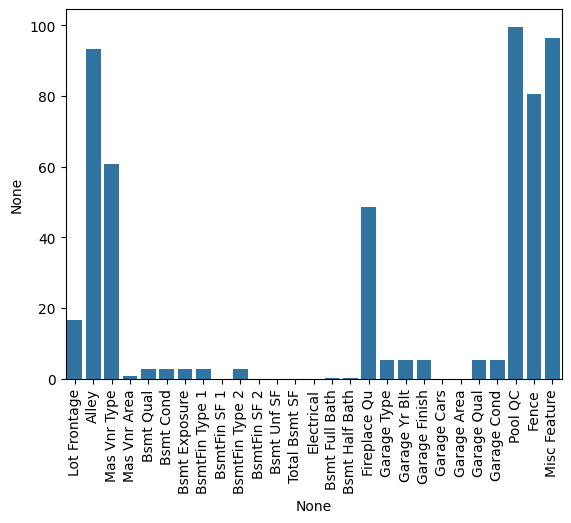

In [75]:
sns.barplot(x=pct_nan.index,y=pct_nan)
plt.xticks(rotation=90)
plt.show()